## **Q5: How do learner numbers, disability profiles, access to a SPED Center or ILRC within a 3-kilometer radius, and enrollment in schools hosting these centers vary across municipalities of different income classes?**

**Datasets used in this notebook**

| File | Role |
|---|---|
| `public_school_coordinates.parquet` / `private_school_coordinates.parquet` | School-level PSGC geography, and the authoritative source for `income_class` (per DOF DO 074-2024). |
| `sned_database_tidy_long.parquet` |  SNED learner counts by school, disability category, diagnosis type, grade, and sex. Queried through DuckDB throughout so the raw table is never loaded into pandas. |
| `sned_access_public_lgu_counts.csv` / `sned_access_pubpriv_lgu_counts.csv` | Municipality-level access roll-up, public-only vs. public+private population. |
| `sned_access_public_summary.csv` / `sned_access_pubpriv_summary.csv` | Per-school access summary — nearest facility, count within 3km, access flag |
| `sned_facility_roster.csv` | Per-school ILRC / SPED Center / SNED-implementing tags, used to build municipality- and division-level facility counts. |
| `consolidated_geodata_matched.gpkg` |Barangay-level boundary polygons for every choropleth and network map. (Caveat: NCR and BARMM areas are not cleanly organized here, potentially leading to some discrepancies) |

### **A. Preliminaries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import geopandas as gpd
import duckdb
from IPython.display import display
from scipy import stats

pd.set_option('display.max_columns', None)

REGION_SHORT = {
    'Region I (Ilocos Region)':       'Ilocos Region',
    'Region II (Cagayan Valley)':     'Cagayan Valley',
    'Cordillera Administrative Region (CAR)': 'CAR',
    'Region III (Central Luzon)':     'Central Luzon',
    'National Capital Region (NCR)':  'NCR',
    'Region IV-A (CALABARZON)':       'CALABARZON',
    'MIMAROPA Region':                'MIMAROPA',
    'Region V (Bicol Region)':        'Bicol Region',
    'Region VI (Western Visayas)':    'Western Visayas',
    'Negros Island Region (NIR)':     'NIR',
    'Region VII (Central Visayas)':   'Central Visayas',
    'Region VIII (Eastern Visayas)':  'Eastern Visayas',
    'Region IX (Zamboanga Peninsula)':'Zamboanga Peninsula',
    'Region X (Northern Mindanao)':   'Northern Mindanao',
    'Region XI (Davao Region)':       'Davao Region',
    'Region XII (SOCCSKSARGEN)':      'SOCCSKSARGEN',
    'Region XIII (Caraga)':           'Caraga',
    'Bangsamoro Autonomous Region In Muslim Mindanao (BARMM)': 'BARMM',
}
REGION_ORDER = list(REGION_SHORT.values())

from pyfonts import set_default_font, load_google_font
regular = load_google_font("Inter")
bold    = load_google_font("Inter", weight="bold")
set_default_font(regular)

_ROOT = Path.cwd().parent
DATA  = _ROOT / "data"
FIGURES = DATA.parent / "figures"
PASTEL2 = plt.cm.Set2.colors

In [2]:
# Helpers
ID_LIKE_COLS = [
    'school_id', 'population_school_id', 'facility_school_id', 'beis_school_id',
    'psgc_region', 'psgc_province', 'psgc_municity', 'psgc_barangay',
    'psgc_observed_barangay', 'psgc_observed_municity',
]

PSGC_ZFILL_WIDTH = 10
PSGC_ZFILL_COLS = ['psgc_municity']

def cast_ids_to_str(df, cols=None, zfill_cols=None, zfill_width=PSGC_ZFILL_WIDTH):
    """Cast identifier-like columns to string; zero-pad psgc_municity to 10 digits."""
    cols = cols or ID_LIKE_COLS
    zfill_cols = zfill_cols if zfill_cols is not None else PSGC_ZFILL_COLS
    df = df.copy()
    for c in cols:
        if c not in df.columns:
            continue
        if pd.api.types.is_float_dtype(df[c]) or pd.api.types.is_integer_dtype(df[c]):
            df[c] = df[c].astype('Int64').astype('string')
        else:
            df[c] = df[c].astype('string')
        if c in zfill_cols:
            df[c] = df[c].str.zfill(zfill_width)
    return df


def merge_with_diagnostics(left, right, on, left_name, right_name, how='left'):
    """
    Left-join left -> right, print match/mismatch counts, and return the
    unmatched rows. "Matched" means the join KEY was found — it says nothing
    about whether the payload column itself is non-null.
    """
    merged = left.merge(right, on=on, how=how, indicator='_merge_diag')
    n_left = len(left)
    n_matched = (merged['_merge_diag'] == 'both').sum()
    n_unmatched = (merged['_merge_diag'] == 'left_only').sum()

    print(f"[MERGE] {left_name} -> {right_name}  (on={on})")
    print(f"  {n_matched:,} / {n_left:,} rows matched ({n_matched/n_left:.1%})")
    print(f"  {n_unmatched:,} rows unmatched ({n_unmatched/n_left:.1%})")

    unmatched = merged.loc[merged['_merge_diag'] == 'left_only'].drop(columns='_merge_diag').copy()
    merged = merged.drop(columns='_merge_diag')
    return merged, unmatched


def to_nullable_boolean(df, cols):
    """Cast flag columns to pandas' nullable 'boolean' dtype; warns if it finds real nulls."""
    df = df.copy()
    for c in cols:
        if c not in df.columns:
            continue
        df[c] = df[c].astype('boolean')
        n_null = df[c].isna().sum()
        if n_null:
            print(f"[WARNING] '{c}' has {n_null:,} null values after boolean casting.")
    return df

import re

def _class_rank(label):
    """Extract leading ordinal digit (1st, 2nd, ...); non-ordinal labels sort last."""
    if pd.isna(label):
        return np.inf
    m = re.match(r'\s*(\d+)', str(label))
    return int(m.group(1)) if m else np.inf

def _mode_or_first(s):
    m = s.mode()
    return m.iloc[0] if len(m) else np.nan

### **B. Income-class layer**

In [3]:
pub_coords  = cast_ids_to_str(pd.read_parquet(DATA / "external" / "public_school_coordinates.parquet"))
priv_coords = cast_ids_to_str(pd.read_parquet(DATA / "external" / "private_school_coordinates.parquet"))

pub_coords['sector']  = 'Public'
priv_coords['sector'] = 'Private'

REF_COLS = ['school_id', 'school_name', 'sector', 'psgc_region_name', 'psgc_province_name',
            'psgc_municity', 'psgc_municity_name', 'income_class', 'urban_rural']

school_income_ref = pd.concat([pub_coords[REF_COLS], priv_coords[REF_COLS]], ignore_index=True)

school_income_ref['is_sga_unclassified'] = (
    school_income_ref['income_class'].str.contains('sga', case=False, na=False)
)

SGA_LABEL = 'SGA (No Income Classification)'
MISSING_SOURCE_LABEL = 'Missing (blank in source)'
UNMATCHED_LABEL = 'Unmatched (failed merge)'

school_income_ref['income_class_display'] = np.select(
    [school_income_ref['is_sga_unclassified'], school_income_ref['income_class'].notna()],
    [SGA_LABEL, school_income_ref['income_class']],
    default=MISSING_SOURCE_LABEL,
)

school_income_ref['is_urban_rural_unclassified'] = school_income_ref['urban_rural'] == '-'

print("SGA (no income classification) count by sector:")
print(school_income_ref.groupby('sector')['is_sga_unclassified'].sum(), '\n')

print("Genuinely blank income_class count by sector:")
print(school_income_ref.groupby('sector').apply(lambda g: (g['income_class_display'] == MISSING_SOURCE_LABEL).sum()), '\n')

print("Urban/rural '-' count by sector:")
print(school_income_ref.groupby('sector')['is_urban_rural_unclassified'].sum(), '\n')

n_dup_ids = school_income_ref['school_id'].duplicated().sum()
if n_dup_ids:
    print(f"[WARNING] {n_dup_ids} duplicate school_id values across public+private coordinates.")

SGA (no income classification) count by sector:
sector
Private      1
Public     116
Name: is_sga_unclassified, dtype: int64 

Genuinely blank income_class count by sector:
sector
Private    228
Public     279
dtype: int64 

Urban/rural '-' count by sector:
sector
Private    51
Public     29
Name: is_urban_rural_unclassified, dtype: int64 



In [7]:
# Diagnosing Missing (blank in source)
missing_income_schools = school_income_ref[school_income_ref['income_class_display'] == MISSING_SOURCE_LABEL]
print(f"{len(missing_income_schools):,} schools have a genuinely blank income_class "
      f"({(missing_income_schools['psgc_municity'].isna()).sum():,} of them also lack a resolved psgc_municity).")
display(missing_income_schools[['school_id', 'school_name', 'sector', 'psgc_municity', 'psgc_municity_name']])

missing_income_munis = (
    school_income_ref.groupby(['psgc_municity', 'psgc_municity_name'])['income_class_display']
    .apply(lambda s: (s == MISSING_SOURCE_LABEL).all())
)
missing_income_munis = missing_income_munis[missing_income_munis].reset_index()
print(f"{len(missing_income_munis):,} whole municipalities have every school missing income_class.")

507 schools have a genuinely blank income_class (507 of them also lack a resolved psgc_municity).


,school_id,school_name,sector,psgc_municity,psgc_municity_name
414,100432,Bugnay Elementary School,Public,<NA>,NaN
423,100441,Langlangca Elementary School,Public,<NA>,NaN
543,100572,Kilang Primary School,Public,<NA>,NaN
2499,102656,Mabuno Elementary School,Public,<NA>,NaN
2959,103146,Candanum Elementary School,Public,<NA>,NaN
...,...,...,...,...,...
59218,467552,"Love Grace Christian School, Inc.",Private,<NA>,NaN
59380,472036,Southway College of Technology,Private,<NA>,NaN
59516,479525,Vision Thinkers Hub and Integrated School Inc.,Private,<NA>,NaN
59658,482679,Cordis Mariae School: A Subsidiary Cooperative...,Private,<NA>,NaN


0 whole municipalities have every school missing income_class.


In [8]:
# Region x income class
region_income_crosstab = pd.crosstab(
    school_income_ref['psgc_region_name'].map(REGION_SHORT).fillna(school_income_ref['psgc_region_name']),
    school_income_ref['income_class_display'],
    normalize='index'
) * 100
region_income_crosstab = region_income_crosstab.reindex(REGION_ORDER)
display(region_income_crosstab.round(1))

income_class_display,1st,2nd,3rd,4th,5th,SGA (No Income Classification)
psgc_region_name,,,,,,
Ilocos Region,69.1,18.4,10.3,2.2,0.1,0.0
Cagayan Valley,71.7,19.1,5.7,2.6,0.9,0.0
CAR,42.9,12.3,21.5,20.6,2.7,0.0
Central Luzon,83.5,9.1,4.9,2.5,0.0,0.0
NCR,100.0,0.0,0.0,0.0,0.0,0.0
CALABARZON,81.8,6.3,6.8,4.8,0.4,0.0
MIMAROPA,73.9,12.0,5.2,5.7,3.2,0.0
Bicol Region,61.1,15.1,14.6,8.7,0.4,0.0
Western Visayas,47.4,25.7,20.2,6.4,0.3,0.0


In [9]:
# Municipality-level income class
muni_income_consistency = (
    school_income_ref
    .groupby(['psgc_municity', 'psgc_municity_name'])['income_class_display']
    .nunique()
    .reset_index(name='n_distinct_income_classes')
)
inconsistent_munis = muni_income_consistency[muni_income_consistency['n_distinct_income_classes'] > 1]
print(f"{len(inconsistent_munis)} / {len(muni_income_consistency)} municipalities show >1 income_class value across their schools.")
if len(inconsistent_munis):
    display(inconsistent_munis)

muni_income = (
    school_income_ref
    .groupby(['psgc_municity', 'psgc_municity_name'], as_index=False)
    .agg(income_class_display=('income_class_display', _mode_or_first),
         urban_rural=('urban_rural', _mode_or_first),
         psgc_region_name=('psgc_region_name', _mode_or_first))
)
muni_income['region_short'] = muni_income['psgc_region_name'].map(REGION_SHORT).fillna(muni_income['psgc_region_name'])
muni_income['income_rank'] = muni_income['income_class_display'].map(_class_rank)

school_income_lookup = (
    school_income_ref[['school_id', 'sector', 'income_class_display', 'is_sga_unclassified',
                        'urban_rural', 'is_urban_rural_unclassified']]
    .drop_duplicates('school_id')
)

display(muni_income.head())

0 / 1655 municipalities show >1 income_class value across their schools.


,psgc_municity,psgc_municity_name,income_class_display,urban_rural,psgc_region_name,region_short,income_rank
0,0102801000,Adams,4th,R,Region I (Ilocos Region),Ilocos Region,4.0
1,0102802000,Bacarra,2nd,R,Region I (Ilocos Region),Ilocos Region,2.0
2,0102803000,Badoc,1st,R,Region I (Ilocos Region),Ilocos Region,1.0
3,0102804000,Bangui,2nd,R,Region I (Ilocos Region),Ilocos Region,2.0
4,0102805000,City of Batac,3rd,R,Region I (Ilocos Region),Ilocos Region,3.0


In [10]:
_ordinal_classes = (
    school_income_ref.loc[~school_income_ref['is_sga_unclassified'], 'income_class_display']
    .loc[lambda s: s != MISSING_SOURCE_LABEL]
    .unique()
)
INCOME_CLASS_ORDER = sorted(_ordinal_classes, key=_class_rank)
INCOME_CLASS_PLOT_ORDER = INCOME_CLASS_ORDER + [SGA_LABEL, MISSING_SOURCE_LABEL, UNMATCHED_LABEL]
INCOME_CLASS_VIZ_ORDER = INCOME_CLASS_ORDER + [SGA_LABEL]
EXCLUDED_FROM_VIZ = [MISSING_SOURCE_LABEL, UNMATCHED_LABEL]

def exclude_missing_unmatched(df, col='income_class_display'):
    """Drop Missing/Unmatched rows before plotting; keep them in tables everywhere else."""
    return df[~df[col].isin(EXCLUDED_FROM_VIZ)].copy()

print("Ordinal income classes (trend tests):", INCOME_CLASS_ORDER)
print("Full table order:", INCOME_CLASS_PLOT_ORDER)
print("Chart order (Missing/Unmatched excluded):", INCOME_CLASS_VIZ_ORDER)

# --- Shared color scheme, used consistently across every chart in this notebook ---
INCOME_CLASS_COLORS = {
    cls: tuple(color) for cls, color in zip(INCOME_CLASS_ORDER, plt.cm.coolwarm(np.linspace(0.15, 0.85, len(INCOME_CLASS_ORDER))))
}
INCOME_CLASS_COLORS[SGA_LABEL] = (0.54, 0.53, 0.51, 1.0)  # neutral gray — SGA isn't a position on the rich/poor scale

PASTEL2 = plt.cm.Pastel2.colors
DIVERGING_CMAP = 'coolwarm'

# Short display labels for chart ticks/legends only — never used for grouping/merging.
CHART_LABEL_OVERRIDES = {SGA_LABEL: 'SGA'}
def chart_labels(labels):
    return [CHART_LABEL_OVERRIDES.get(l, l) for l in labels]

Ordinal income classes (trend tests): ['1st', '2nd', '3rd', '4th', '5th']
Full table order: ['1st', '2nd', '3rd', '4th', '5th', 'SGA (No Income Classification)', 'Missing (blank in source)', 'Unmatched (failed merge)']
Chart order (Missing/Unmatched excluded): ['1st', '2nd', '3rd', '4th', '5th', 'SGA (No Income Classification)']


### **C. Loading municipal data**

In [11]:
pub_lgu     = cast_ids_to_str(pd.read_csv(DATA / "sned_access_public_lgu_counts.csv"))
pubpriv_lgu = cast_ids_to_str(pd.read_csv(DATA / "sned_access_pubpriv_lgu_counts.csv"))

pub_summary     = cast_ids_to_str(pd.read_csv(DATA / "sned_access_public_summary.csv"))
pubpriv_summary = cast_ids_to_str(pd.read_csv(DATA / "sned_access_pubpriv_summary.csv"))
pub_summary     = to_nullable_boolean(pub_summary, ['has_sned_access_3km'])
pubpriv_summary = to_nullable_boolean(pubpriv_summary, ['has_sned_access_3km'])

facility_roster = cast_ids_to_str(pd.read_csv(DATA / "sned_facility_roster.csv"))

muni_income_for_merge = muni_income[['psgc_municity', 'income_class_display', 'urban_rural', 'region_short', 'income_rank']]

pub_lgu_enriched, unmatched_pub_lgu_income = merge_with_diagnostics(
    pub_lgu, muni_income_for_merge, on='psgc_municity',
    left_name='sned_access_public_lgu_counts', right_name='muni_income')

pubpriv_lgu_enriched, unmatched_pubpriv_lgu_income = merge_with_diagnostics(
    pubpriv_lgu, muni_income_for_merge, on='psgc_municity',
    left_name='sned_access_pubpriv_lgu_counts', right_name='muni_income')

pub_summary_enriched, unmatched_pub_summary_income = merge_with_diagnostics(
    pub_summary, school_income_lookup.rename(columns={'school_id': 'population_school_id'}),
    on='population_school_id',
    left_name='sned_access_public_summary', right_name='school_income_lookup')

pubpriv_summary_enriched, unmatched_pubpriv_summary_income = merge_with_diagnostics(
    pubpriv_summary, school_income_lookup.rename(columns={'school_id': 'population_school_id'}),
    on='population_school_id',
    left_name='sned_access_pubpriv_summary', right_name='school_income_lookup')

facility_roster_enriched, unmatched_facility_roster_income = merge_with_diagnostics(
    facility_roster, school_income_lookup, on='school_id',
    left_name='sned_facility_roster', right_name='school_income_lookup')

for _df in [pub_lgu_enriched, pubpriv_lgu_enriched, pub_summary_enriched,
            pubpriv_summary_enriched, facility_roster_enriched]:
    _df['income_class_display'] = _df['income_class_display'].fillna(UNMATCHED_LABEL)

print()
for name, df in [('pub_lgu_enriched', pub_lgu_enriched), ('pubpriv_lgu_enriched', pubpriv_lgu_enriched),
                  ('pub_summary_enriched', pub_summary_enriched), ('pubpriv_summary_enriched', pubpriv_summary_enriched),
                  ('facility_roster_enriched', facility_roster_enriched)]:
    n_unmatched = (df['income_class_display'] == UNMATCHED_LABEL).sum()
    print(f"{name}: {n_unmatched:,} / {len(df):,} rows unmatched ({n_unmatched/len(df):.2%})")

print("\nUnmatched rows, shown explicitly rather than only counted:")
for name, udf in [('pub_lgu', unmatched_pub_lgu_income), ('pubpriv_lgu', unmatched_pubpriv_lgu_income),
                   ('pub_summary', unmatched_pub_summary_income), ('pubpriv_summary', unmatched_pubpriv_summary_income),
                   ('facility_roster', unmatched_facility_roster_income)]:
    if len(udf):
        print(f"-- {name} ({len(udf)} rows) --")
        display(udf)

[MERGE] sned_access_public_lgu_counts -> muni_income  (on=psgc_municity)
  1,634 / 1,634 rows matched (100.0%)
  0 rows unmatched (0.0%)
[MERGE] sned_access_pubpriv_lgu_counts -> muni_income  (on=psgc_municity)
  1,635 / 1,635 rows matched (100.0%)
  0 rows unmatched (0.0%)
[MERGE] sned_access_public_summary -> school_income_lookup  (on=population_school_id)
  46,537 / 46,537 rows matched (100.0%)
  0 rows unmatched (0.0%)
[MERGE] sned_access_pubpriv_summary -> school_income_lookup  (on=population_school_id)
  54,119 / 54,119 rows matched (100.0%)
  0 rows unmatched (0.0%)
[MERGE] sned_facility_roster -> school_income_lookup  (on=school_id)
  2,629 / 2,629 rows matched (100.0%)
  0 rows unmatched (0.0%)

pub_lgu_enriched: 0 / 1,634 rows unmatched (0.00%)
pubpriv_lgu_enriched: 0 / 1,635 rows unmatched (0.00%)
pub_summary_enriched: 0 / 46,537 rows unmatched (0.00%)
pubpriv_summary_enriched: 0 / 54,119 rows unmatched (0.00%)
facility_roster_enriched: 0 / 2,629 rows unmatched (0.00%)

Unma

- **Income tier** — 1st-3rd class = "Higher income"; 4th-5th = "Lower income"
  (`HIGHER_INCOME_MAX_RANK`, a documented, single-constant cutoff — adjust freely).
- **Accessibility tier** — split at the **median** `pct_without_access` across
  municipalities, using the public+private population definition (every SNED
  facility is public, so this reflects the full universe of learners who might
  need one), so the two groups are balanced by construction rather than an
  arbitrary round number.

In [13]:
# Municipal income tier and accessibility tier
HIGHER_INCOME_MAX_RANK = 3  # ranks 1-3 ("1st","2nd","3rd") = "Higher income"

muni_tiers, unmatched_tier_access = merge_with_diagnostics(
    muni_income, pub_lgu_enriched[['psgc_municity', 'pct_without_access', 'n_public_schools']],
    on='psgc_municity', left_name='muni_income', right_name='pub_lgu_enriched')
if len(unmatched_tier_access):
    display(unmatched_tier_access.head(5))

muni_tiers['income_tier'] = np.select(
    [muni_tiers['income_rank'] <= HIGHER_INCOME_MAX_RANK,
     np.isfinite(muni_tiers['income_rank']) & (muni_tiers['income_rank'] > HIGHER_INCOME_MAX_RANK)],
    ['Higher income', 'Lower income'],
    default='Not classified (SGA/Missing)'
)

ACCESS_MEDIAN = muni_tiers['pct_without_access'].median()
print(f"Median % of public schools without 3km access (accessibility-tier cutoff): {ACCESS_MEDIAN:.1%}")
muni_tiers['accessibility_tier'] = np.where(
    muni_tiers['pct_without_access'] <= ACCESS_MEDIAN, 'High accessibility', 'Low accessibility'
)

QUADRANT_LABELS = {
    ('Higher income', 'High accessibility'): 'Well-served',
    ('Higher income', 'Low accessibility'): 'High-income access gap',
    ('Lower income', 'High accessibility'): 'Low-income but well-served',
    ('Lower income', 'Low accessibility'): 'Priority gap',
}
muni_tiers['quadrant'] = muni_tiers.apply(
    lambda r: QUADRANT_LABELS.get((r['income_tier'], r['accessibility_tier']), 'Not classified (SGA/Missing income)'), axis=1
)


display(muni_tiers['quadrant'].value_counts())

[MERGE] muni_income -> pub_lgu_enriched  (on=psgc_municity)
  1,634 / 1,655 rows matched (98.7%)
  21 rows unmatched (1.3%)


,psgc_municity,psgc_municity_name,income_class_display,urban_rural,psgc_region_name,region_short,income_rank,pct_without_access,n_public_schools
1218,1380602000,Binondo,1st,U,National Capital Region (NCR),NCR,1.0,NaN,NaN
1443,1705321000,Kalayaan,4th,R,MIMAROPA Region,MIMAROPA,4.0,NaN,NaN
1580,1906601000,Indanan,1st,R,Bangsamoro Autonomous Region In Muslim Mindana...,BARMM,1.0,NaN,NaN
1581,1906602000,Jolo,1st,U,Bangsamoro Autonomous Region In Muslim Mindana...,BARMM,1.0,NaN,NaN
1582,1906603000,Kalingalan Caluang,3rd,R,Bangsamoro Autonomous Region In Muslim Mindana...,BARMM,3.0,NaN,NaN


Median % of public schools without 3km access (accessibility-tier cutoff): 81.8%


quadrant
Well-served                            684
High-income access gap                 646
Priority gap                           177
Low-income but well-served             140
Not classified (SGA/Missing income)      8
Name: count, dtype: int64

### **D. Basic findings**

In [16]:
# Income class landscape and chloropleth
income_class_muni_counts = (
    muni_income['income_class_display'].value_counts()
    .reindex(INCOME_CLASS_PLOT_ORDER).fillna(0).astype(int).rename('n_municipalities')
)
income_class_muni_counts_pct = (income_class_muni_counts / income_class_muni_counts.sum() * 100).rename('pct_of_municipalities')
income_class_universe_summary = pd.concat([income_class_muni_counts, income_class_muni_counts_pct], axis=1)
display(income_class_universe_summary.round(1))

for cls, row in income_class_universe_summary.iterrows():
    if row['n_municipalities'] > 0:
        print(f"{cls}: {row['n_municipalities']:,.0f} municipalities ({row['pct_of_municipalities']:.1f}% of all municipalities)")
print(f"\n[N] {len(muni_income):,} municipalities | {len(school_income_ref):,} schools (public+private) considered in this section.")

,n_municipalities,pct_of_municipalities
income_class_display,,
1st,792,47.9
2nd,271,16.4
3rd,267,16.1
4th,252,15.2
5th,65,3.9
SGA (No Income Classification),8,0.5
Missing (blank in source),0,0.0
Unmatched (failed merge),0,0.0


1st: 792 municipalities (47.9% of all municipalities)
2nd: 271 municipalities (16.4% of all municipalities)
3rd: 267 municipalities (16.1% of all municipalities)
4th: 252 municipalities (15.2% of all municipalities)
5th: 65 municipalities (3.9% of all municipalities)
SGA (No Income Classification): 8 municipalities (0.5% of all municipalities)

[N] 1,655 municipalities | 60,421 schools (public+private) considered in this section.


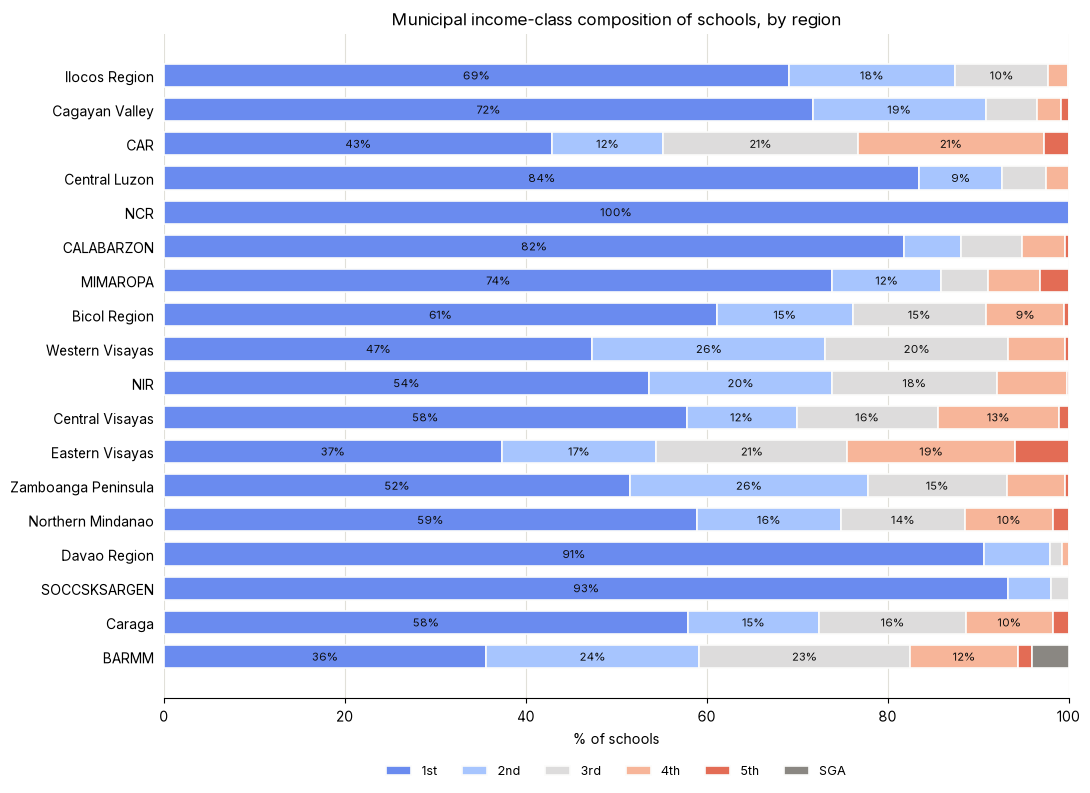

[N] 59,914 schools plotted (of 60,421 total; 507 Missing/Unmatched excluded from this chart).


In [17]:
_viz_rows = school_income_ref[~school_income_ref['income_class_display'].isin(EXCLUDED_FROM_VIZ)]

region_income_crosstab_viz = pd.crosstab(
    _viz_rows['psgc_region_name'].map(REGION_SHORT).fillna(_viz_rows['psgc_region_name']),
    _viz_rows['income_class_display'],
    normalize='index'
) * 100
region_income_crosstab_viz = region_income_crosstab_viz.reindex(REGION_ORDER)[INCOME_CLASS_VIZ_ORDER]

fig, ax = plt.subplots(figsize=(11, 8))
left = np.zeros(len(region_income_crosstab_viz))
bar_positions = np.arange(len(region_income_crosstab_viz))

for cls in INCOME_CLASS_VIZ_ORDER:
    vals = region_income_crosstab_viz[cls].values
    ax.barh(bar_positions, vals, left=left, height=0.68, color=INCOME_CLASS_COLORS[cls], label=cls,
            edgecolor='#fcfcfb', linewidth=1.2)
    for y, v, l in zip(bar_positions, vals, left):
        if v >= 8:
            ax.text(l + v / 2, y, f'{v:.0f}%', ha='center', va='center', fontsize=8, color='#0b0b0b')
    left += vals

ax.set_yticks(bar_positions)
ax.set_yticklabels(region_income_crosstab_viz.index)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel('% of schools')
ax.set_title('Municipal income-class composition of schools, by region')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(left=False)
ax.xaxis.grid(True, color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(chart_labels(INCOME_CLASS_VIZ_ORDER), loc='upper center', bbox_to_anchor=(0.5, -0.08),
          ncol=len(INCOME_CLASS_VIZ_ORDER), frameon=False, fontsize=9)
plt.tight_layout()
# plt.savefig(FIGURES / "rq5_region_income_composition_stacked.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"[N] {len(_viz_rows):,} schools plotted (of {len(school_income_ref):,} total; "
      f"{len(school_income_ref) - len(_viz_rows):,} Missing/Unmatched excluded from this chart).")

In [18]:
geodata = gpd.read_file(DATA / "external" / "consolidated_geodata_matched.gpkg")

print(geodata['geo_level'].value_counts(dropna=False))
null_geo = geodata[geodata['geo_level'].isna()]
print(f"\n{len(null_geo):,} rows have geo_level == NaN — concentrated in exactly the places you'd expect")
print("to disappear from a naive geo_level=='Bgy'-only choropleth: NCR (no barangay-level rows resolved),")
print("BARMM, and several HUC-heavy provinces:")
print(null_geo['adm1_en'].value_counts().head(5))

# Robust dissolve
usable = geodata[geodata['geometry'].notna() & geodata['adm3_psgc'].notna()].copy()
print(f"\n{len(usable):,} usable rows (vs. {(geodata['geo_level']=='Bgy').sum():,} under a geo_level=='Bgy'-only filter).")

NIR_PROVINCES = {"Negros Occidental", "Negros Oriental", "Siquijor"}
is_nir = usable["adm2_en"].isin(NIR_PROVINCES)
print(f"{is_nir.sum():,} barangay rows reassigned to NIR (still coded under old Region 06/07 in this file).")
usable.loc[is_nir, "adm1_en"] = "Negros Island Region (NIR)"
usable.loc[is_nir, "adm3_psgc"] = "18" + usable.loc[is_nir, "adm3_psgc"].astype('string').str[2:]

usable['psgc_code'] = usable['adm3_psgc'].astype('Int64').astype('string').str.zfill(10)

muni_geo_dissolved = usable.dissolve(by='psgc_code').reset_index()
print(f"{len(muni_geo_dissolved):,} dissolved municipality geometries.")

muni_geo_income, unmatched_muni_geo = merge_with_diagnostics(
    muni_geo_dissolved, muni_income.rename(columns={'psgc_municity': 'psgc_code'}),
    on='psgc_code', left_name='muni_geo_dissolved', right_name='muni_income')
if len(unmatched_muni_geo):
    print("Still unmatched after the fix (usually a single corrupted-hierarchy row, not a systematic gap):")
    display(unmatched_muni_geo[['psgc_code', 'name', 'adm1_en', 'adm2_en']])

geo_level
Bgy    38466
NaN     3582
Name: count, dtype: int64

3,582 rows have geo_level == NaN — concentrated in exactly the places you'd expect
to disappear from a naive geo_level=='Bgy'-only choropleth: NCR (no barangay-level rows resolved),
BARMM, and several HUC-heavy provinces:
adm1_en
National Capital Region (NCR)                              1316
Bangsamoro Autonomous Region In Muslim Mindanao (BARMM)     441
Region IV-A (CALABARZON)                                    377
Region VI (Western Visayas)                                 241
Region XI (Davao Region)                                    158
Name: count, dtype: int64

42,048 usable rows (vs. 38,466 under a geo_level=='Bgy'-only filter).
1,353 barangay rows reassigned to NIR (still coded under old Region 06/07 in this file).
1,582 dissolved municipality geometries.
[MERGE] muni_geo_dissolved -> muni_income  (on=psgc_code)
  1,581 / 1,582 rows matched (99.9%)
  1 rows unmatched (0.1%)
Still unmatched after the fix (usually 

,psgc_code,name,adm1_en,adm2_en
1198,1303901000,NaN,National Capital Region (NCR),National Capital Region (NCR)


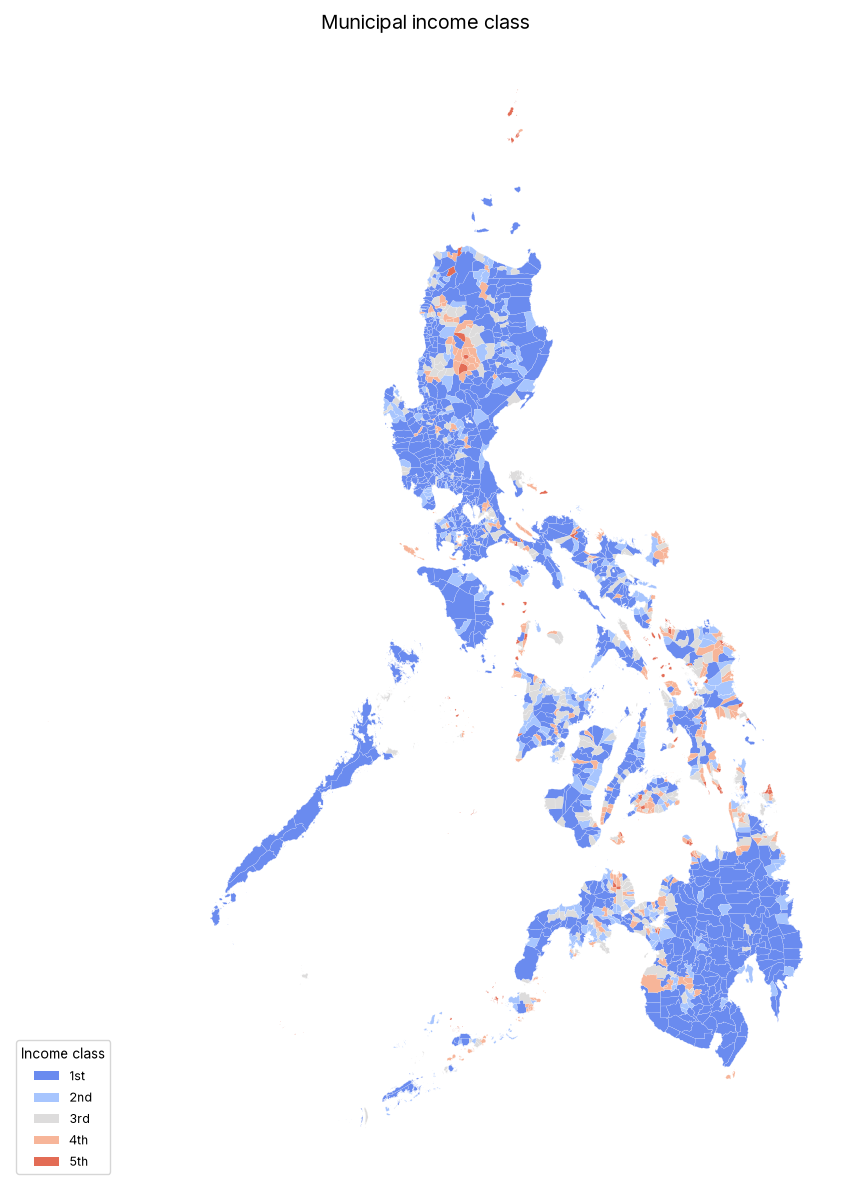

[N] 1,582 municipality polygons drawn (of 1,655 municipalities in muni_income).


In [19]:
import matplotlib.colors as mcolors

INCOME_CLASS_MAP_COLORS = {k: mcolors.to_hex(v) for k, v in INCOME_CLASS_COLORS.items()}
INCOME_CLASS_MAP_COLORS[MISSING_SOURCE_LABEL] = '#d9d9d9'
INCOME_CLASS_MAP_COLORS[UNMATCHED_LABEL] = '#969696'

muni_geo_income['map_color'] = muni_geo_income['income_class_display'].map(INCOME_CLASS_MAP_COLORS)
muni_geo_income['map_color'] = muni_geo_income['map_color'].apply(lambda c: c if isinstance(c, str) else '#ffffff')

fig, ax = plt.subplots(figsize=(10, 12))
muni_geo_income.plot(color=list(muni_geo_income['map_color']), edgecolor='white', linewidth=0.1, ax=ax)
ax.set_axis_off()
ax.set_title('Municipal income class', fontsize=14)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=c, label=chart_labels([lbl])[0]) for lbl, c in INCOME_CLASS_MAP_COLORS.items()
                  if lbl in muni_geo_income['income_class_display'].unique()]
ax.legend(handles=legend_handles, loc='lower left', fontsize=9, title='Income class')
plt.tight_layout()
# plt.savefig(FIGURES / "rq5_income_class_choropleth.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"[N] {len(muni_geo_income):,} municipality polygons drawn (of {len(muni_income):,} municipalities in muni_income).")

In [22]:
# SNED learners, by income class
parquet_path = DATA / "sned_database_tidy_long.parquet"
con = duckdb.connect()

diag_by_school = con.execute(f"""
    SELECT beis_school_id, Diagnosis_Type, SUM(Learner_Count) AS total_learners
    FROM read_parquet('{parquet_path.as_posix()}')
    GROUP BY beis_school_id, Diagnosis_Type
""").fetchdf()
diag_by_school = cast_ids_to_str(diag_by_school)

TOTAL_LEARNERS_NATIONAL = diag_by_school['total_learners'].sum()
print(f"Total SNED learner-records nationally (all diagnosis types, all schools): {TOTAL_LEARNERS_NATIONAL:,.0f}")

school_total_learners = (
    diag_by_school.groupby('beis_school_id', as_index=False)['total_learners'].sum()
    .rename(columns={'beis_school_id': 'population_school_id', 'total_learners': 'total_sned_learners'})
)

school_total_learners_geo, unmatched_learners_geo = merge_with_diagnostics(
    school_total_learners.rename(columns={'population_school_id': 'school_id'}),
    school_income_ref[['school_id', 'psgc_municity', 'psgc_municity_name', 'income_class_display']],
    on='school_id', left_name='school_total_learners', right_name='school_income_ref')
if len(unmatched_learners_geo):
    print(f"\n{len(unmatched_learners_geo):,} schools from the parquet aren't in the coordinates reference at all "
          f"(no municipality can be assigned) — shown below:")
    display(unmatched_learners_geo.head(5))

school_total_learners_geo['income_class_display'] = school_total_learners_geo['income_class_display'].fillna(UNMATCHED_LABEL)
school_total_learners_geo['psgc_municity'] = school_total_learners_geo['psgc_municity'].fillna('UNMATCHED')

muni_learner_totals = (
    school_total_learners_geo
    .groupby(['psgc_municity', 'psgc_municity_name', 'income_class_display'], dropna=False, as_index=False)
    ['total_sned_learners'].sum()
)

learners_by_income_class = (
    muni_learner_totals.groupby('income_class_display', dropna=False)['total_sned_learners']
    .agg(total_learners='sum', n_municipalities='count', mean_per_muni='mean',
         median_per_muni='median', std_per_muni='std')
    .reindex(INCOME_CLASS_PLOT_ORDER)
    .reset_index()
)
learners_by_income_class['pct_of_total_learners'] = (
    learners_by_income_class['total_learners'] / learners_by_income_class['total_learners'].sum() * 100
)
display(learners_by_income_class)

for _, row in learners_by_income_class.iterrows():
    if pd.notna(row['total_learners']) and row['total_learners'] > 0:
        print(f"{row['income_class_display']}: {row['total_learners']:,.0f} SNED learners "
              f"({row['pct_of_total_learners']:.1f}% of total) across {row['n_municipalities']:,.0f} municipalities "
              f"— mean {row['mean_per_muni']:,.0f}, median {row['median_per_muni']:,.0f} learners/municipality "
              f"(std {row['std_per_muni']:,.0f})")

print(f"[N] {len(school_total_learners):,} schools | {TOTAL_LEARNERS_NATIONAL:,.0f} total SNED learner-records considered.")

Total SNED learner-records nationally (all diagnosis types, all schools): 523,939
[MERGE] school_total_learners -> school_income_ref  (on=school_id)
  59,633 / 59,997 rows matched (99.4%)
  364 rows unmatched (0.6%)

364 schools from the parquet aren't in the coordinates reference at all (no municipality can be assigned) — shown below:


,school_id,total_sned_learners,psgc_municity,psgc_municity_name,income_class_display
7590,108248,59.0,<NA>,NaN,NaN
30552,133221,3.0,<NA>,NaN,NaN
34244,137344,0.0,<NA>,NaN,NaN
34245,137345,2.0,<NA>,NaN,NaN
34246,137346,1.0,<NA>,NaN,NaN


,income_class_display,total_learners,n_municipalities,mean_per_muni,median_per_muni,std_per_muni,pct_of_total_learners
0,1st,393438.0,792,496.765152,222.0,940.770524,75.092329
1,2nd,63095.0,271,232.822878,111.0,335.162865,12.042432
2,3rd,41018.0,267,153.625468,85.0,181.192007,7.828774
3,4th,21269.0,252,84.400794,50.0,100.929239,4.059442
4,5th,2067.0,65,31.800000,21.0,36.832900,0.394512
5,SGA (No Income Classification),151.0,8,18.875000,14.5,8.903250,0.028820
6,Missing (blank in source),384.0,1,384.000000,384.0,NaN,0.073291
7,Unmatched (failed merge),2517.0,1,2517.000000,2517.0,NaN,0.480399


1st: 393,438 SNED learners (75.1% of total) across 792 municipalities — mean 497, median 222 learners/municipality (std 941)
2nd: 63,095 SNED learners (12.0% of total) across 271 municipalities — mean 233, median 111 learners/municipality (std 335)
3rd: 41,018 SNED learners (7.8% of total) across 267 municipalities — mean 154, median 85 learners/municipality (std 181)
4th: 21,269 SNED learners (4.1% of total) across 252 municipalities — mean 84, median 50 learners/municipality (std 101)
5th: 2,067 SNED learners (0.4% of total) across 65 municipalities — mean 32, median 21 learners/municipality (std 37)
SGA (No Income Classification): 151 SNED learners (0.0% of total) across 8 municipalities — mean 19, median 14 learners/municipality (std 9)
Missing (blank in source): 384 SNED learners (0.1% of total) across 1 municipalities — mean 384, median 384 learners/municipality (std nan)
Unmatched (failed merge): 2,517 SNED learners (0.5% of total) across 1 municipalities — mean 2,517, median 2,

In [23]:
unmatched_learners_geo["total_sned_learners"].sum()

np.float64(2517.0)

In [24]:
# Top disability category per income class
con = duckdb.connect()

category_program_by_school = con.execute(f"""
    SELECT beis_school_id, Diagnosis_Type, Category, Program, SUM(Learner_Count) AS total_learners
    FROM read_parquet('{parquet_path.as_posix()}')
    WHERE Learner_Count > 0
    GROUP BY beis_school_id, Diagnosis_Type, Category, Program
""").fetchdf()
category_program_by_school = cast_ids_to_str(category_program_by_school)

category_by_school = (
    category_program_by_school.groupby(['beis_school_id', 'Diagnosis_Type', 'Category'], as_index=False)
    ['total_learners'].sum()
)
program_by_school = (
    category_program_by_school.groupby(['beis_school_id', 'Diagnosis_Type', 'Program'], as_index=False)
    ['total_learners'].sum()
)

category_by_school_enriched, unmatched_category_income = merge_with_diagnostics(
    category_by_school.rename(columns={'beis_school_id': 'school_id'}),
    school_income_ref[['school_id', 'income_class_display', 'psgc_municity', 'psgc_region_name']],
    on='school_id', left_name='category_by_school', right_name='school_income_ref')
if len(unmatched_category_income):
    print(f"{len(unmatched_category_income):,} category records failed to match a school — shown below:")
    display(unmatched_category_income)
category_by_school_enriched['income_class_display'] = category_by_school_enriched['income_class_display'].fillna(UNMATCHED_LABEL)
category_by_school_enriched['region_short'] = (
    category_by_school_enriched['psgc_region_name'].map(REGION_SHORT).fillna(category_by_school_enriched['psgc_region_name'])
)

[MERGE] category_by_school -> school_income_ref  (on=school_id)
  139,045 / 139,686 rows matched (99.5%)
  641 rows unmatched (0.5%)
641 category records failed to match a school — shown below:


,school_id,Diagnosis_Type,Category,total_learners,income_class_display,psgc_municity,psgc_region_name
20287,108248,With Diagnosis from Licensed Medical Specialist,Autism Spectrum Disorder,2.0,NaN,<NA>,NaN
20288,108248,With Diagnosis from Licensed Medical Specialist,Hearing Impairment,1.0,NaN,<NA>,NaN
20289,108248,With Manifestations,Difficulty in Applying Knowledge,35.0,NaN,<NA>,NaN
20290,108248,With Manifestations,"Difficulty in Remembering, Concentrating, Payi...",3.0,NaN,<NA>,NaN
20291,108248,With Manifestations,Difficulty in Seeing,18.0,NaN,<NA>,NaN
...,...,...,...,...,...,...,...
139681,503072,With Diagnosis from Licensed Medical Specialist,Orthopedic/Physical Handicap,2.0,NaN,<NA>,NaN
139682,503072,With Diagnosis from Licensed Medical Specialist,Speech/Language Disorder,2.0,NaN,<NA>,NaN
139683,503072,With Diagnosis from Licensed Medical Specialist,Visual Impairment,3.0,NaN,<NA>,NaN
139684,503072,With Manifestations,Difficulty in Communicating,2.0,NaN,<NA>,NaN


In [25]:
cat_income_totals = (
    category_by_school_enriched.groupby(['income_class_display', 'Diagnosis_Type', 'Category'], dropna=False)['total_learners']
    .sum().reset_index()
)
top_category_per_income = (
    cat_income_totals.loc[cat_income_totals.groupby(['income_class_display', 'Diagnosis_Type'])['total_learners'].idxmax()]
    .sort_values(['Diagnosis_Type', 'income_class_display'])
)
display(top_category_per_income)

for dtype, sub in top_category_per_income.groupby('Diagnosis_Type'):
    print(f"\n{dtype}:")
    for _, row in sub.iterrows():
        if row['income_class_display'] in INCOME_CLASS_VIZ_ORDER:
            print(f"  {row['income_class_display']}: {row['Category']} ({row['total_learners']:,.0f} learners)")

print(f"\n[N] {category_by_school_enriched['school_id'].nunique():,} schools | "
      f"{cat_income_totals['total_learners'].sum():,.0f} category-tagged learner-records considered.")

,income_class_display,Diagnosis_Type,Category,total_learners
0,1st,With Diagnosis from Licensed Medical Specialist,Autism Spectrum Disorder,66035.0
19,2nd,With Diagnosis from Licensed Medical Specialist,Autism Spectrum Disorder,5254.0
38,3rd,With Diagnosis from Licensed Medical Specialist,Autism Spectrum Disorder,3468.0
61,4th,With Diagnosis from Licensed Medical Specialist,Intellectual Disability,1680.0
76,5th,With Diagnosis from Licensed Medical Specialist,Autism Spectrum Disorder,121.0
95,Missing (blank in source),With Diagnosis from Licensed Medical Specialist,Autism Spectrum Disorder,238.0
119,SGA (No Income Classification),With Diagnosis from Licensed Medical Specialist,Speech/Language Disorder,19.0
129,Unmatched (failed merge),With Diagnosis from Licensed Medical Specialist,Autism Spectrum Disorder,484.0
17,1st,With Manifestations,"Difficulty in Remembering, Concentrating, Payi...",121660.0
36,2nd,With Manifestations,"Difficulty in Remembering, Concentrating, Payi...",25850.0



With Diagnosis from Licensed Medical Specialist:
  1st: Autism Spectrum Disorder (66,035 learners)
  2nd: Autism Spectrum Disorder (5,254 learners)
  3rd: Autism Spectrum Disorder (3,468 learners)
  4th: Intellectual Disability (1,680 learners)
  5th: Autism Spectrum Disorder (121 learners)
  SGA (No Income Classification): Speech/Language Disorder (19 learners)

With Manifestations:
  1st: Difficulty in Remembering, Concentrating, Paying Attention and Understanding (121,660 learners)
  2nd: Difficulty in Remembering, Concentrating, Paying Attention and Understanding (25,850 learners)
  3rd: Difficulty in Remembering, Concentrating, Paying Attention and Understanding (15,510 learners)
  4th: Difficulty in Remembering, Concentrating, Paying Attention and Understanding (8,072 learners)
  5th: Difficulty in Remembering, Concentrating, Paying Attention and Understanding (791 learners)
  SGA (No Income Classification): Difficulty in Remembering, Concentrating, Paying Attention and Understa

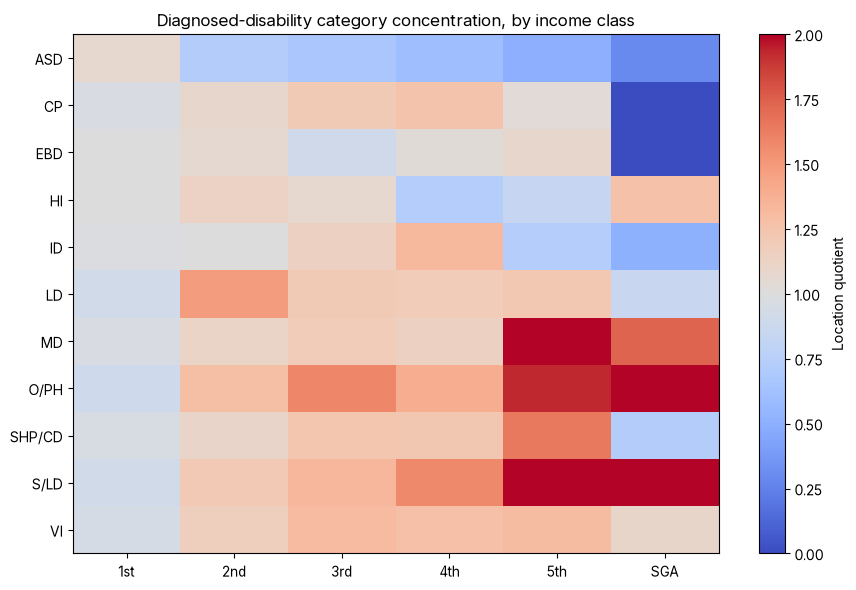

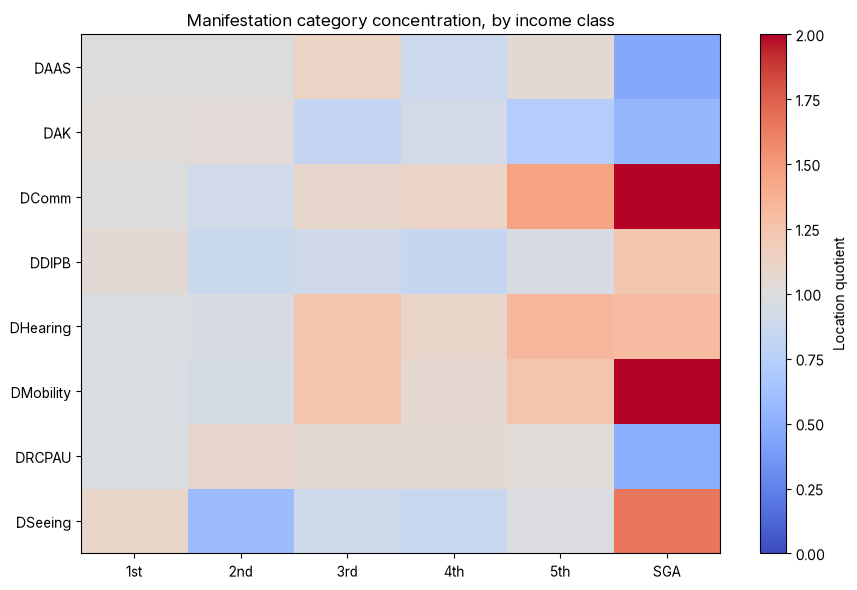

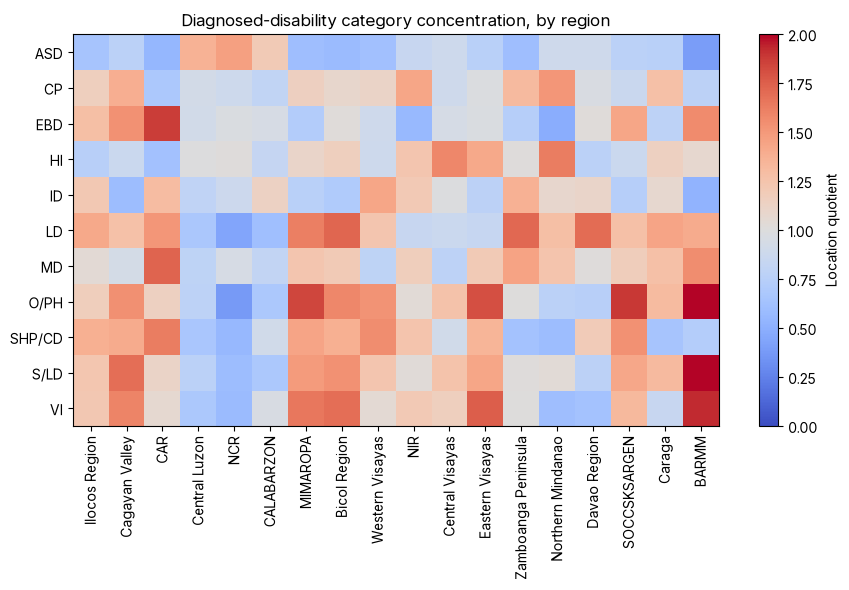

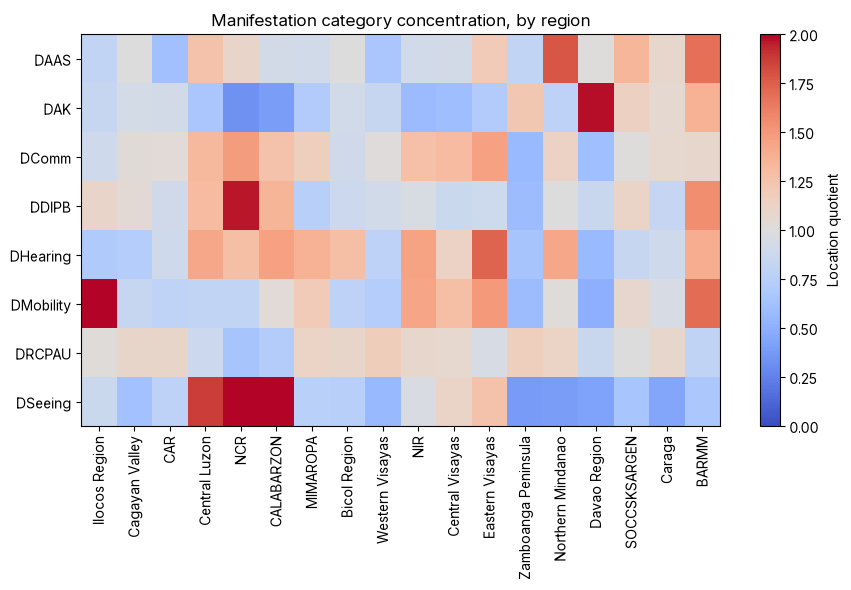

In [27]:
# Disability category concentration, by region, income class
DIAGNOSED_ABBR = {
    "Visual Impairment": "VI", "Hearing Impairment": "HI", "Learning Disability": "LD",
    "Intellectual Disability": "ID", "Autism Spectrum Disorder": "ASD",
    "Orthopedic/Physical Handicap": "O/PH", "Speech/Language Disorder": "S/LD",
    "Multiple Disabilities": "MD",
    "Emotional-Behavioral Disorder": "EBD", "Cerebral Palsy": "CP",
    "Special Health Problem/Chronic Disease": "SHP/CD",
}
MANIFESTATION_ABBR = {
    "Difficulty in Seeing": "DSeeing", "Difficulty in Hearing": "DHearing",
    "Difficulty in Applying Knowledge": "DAK",
    "Difficulty in Remembering, Concentrating, Paying Attention and Understanding": "DRCPAU",
    "Difficulty in Applying Adaptive Skills": "DAAS",
    "Difficulty in Displaying Inter-Personal Behavior": "DDIPB",
    "Difficulty in Mobility (Walking, Climbing and Grasping)": "DMobility",
    "Difficulty in Communicating": "DComm",
}

def category_concentration(df, group_col, group_order, diagnosis_type_filter):
    sub = df[df['Diagnosis_Type'] == diagnosis_type_filter]
    pivot = sub.groupby(['Category', group_col])['total_learners'].sum().unstack(group_col).fillna(0)
    pivot = pivot.reindex(columns=group_order, fill_value=0)
    share_of_category = pivot.div(pivot.sum(axis=1), axis=0) * 100
    overall_group_share = pivot.sum(axis=0) / pivot.sum(axis=0).sum()
    location_quotient = share_of_category.div(overall_group_share * 100, axis=1)
    return {'raw_counts': pivot, 'share_of_category': share_of_category, 'location_quotient': location_quotient}

diagnosed_by_income     = category_concentration(category_by_school_enriched, 'income_class_display', INCOME_CLASS_PLOT_ORDER, 'With Diagnosis from Licensed Medical Specialist')
manifestation_by_income = category_concentration(category_by_school_enriched, 'income_class_display', INCOME_CLASS_PLOT_ORDER, 'With Manifestations')
diagnosed_by_region      = category_concentration(category_by_school_enriched, 'region_short', REGION_ORDER, 'With Diagnosis from Licensed Medical Specialist')
manifestation_by_region  = category_concentration(category_by_school_enriched, 'region_short', REGION_ORDER, 'With Manifestations')

# Heatmap 1: diagnosed disability, by income class (xticks at 0 deg, SGA shown short)
data = diagnosed_by_income['location_quotient'][INCOME_CLASS_VIZ_ORDER].rename(index=DIAGNOSED_ABBR)
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(data.values, aspect='auto', cmap=DIVERGING_CMAP, vmin=0, vmax=2)
ax.set_xticks(range(len(data.columns))); ax.set_xticklabels(chart_labels(data.columns), rotation=0, ha='center')
ax.set_yticks(range(len(data.index))); ax.set_yticklabels(data.index)
ax.set_title('Diagnosed-disability category concentration, by income class')
fig.colorbar(im, ax=ax, label='Location quotient')
plt.tight_layout()
# plt.savefig(FIGURES / "rq5_category_concentration_diagnosed_by_income.png", dpi=300, bbox_inches='tight')
plt.show()

# Heatmap 1.5: manifestation disability, by income class (xticks at 0 deg, SGA shown short)
data = manifestation_by_income['location_quotient'][INCOME_CLASS_VIZ_ORDER].rename(index=MANIFESTATION_ABBR)
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(data.values, aspect='auto', cmap=DIVERGING_CMAP, vmin=0, vmax=2)
ax.set_xticks(range(len(data.columns))); ax.set_xticklabels(chart_labels(data.columns), rotation=0, ha='center')
ax.set_yticks(range(len(data.index))); ax.set_yticklabels(data.index)
ax.set_title('Manifestation category concentration, by income class')
fig.colorbar(im, ax=ax, label='Location quotient')
plt.tight_layout()
# plt.savefig(FIGURES / "rq5_category_concentration_manifestation_by_income.png", dpi=300, bbox_inches='tight')
plt.show()

# Heatmap 2: diagnosed disability, by region
data = diagnosed_by_region['location_quotient'][REGION_ORDER].rename(index=DIAGNOSED_ABBR)
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(data.values, aspect='auto', cmap=DIVERGING_CMAP, vmin=0, vmax=2)
ax.set_xticks(range(len(data.columns))); ax.set_xticklabels(data.columns, rotation=90, ha='center')
ax.set_yticks(range(len(data.index))); ax.set_yticklabels(data.index)
ax.set_title('Diagnosed-disability category concentration, by region')
fig.colorbar(im, ax=ax, label='Location quotient')
plt.tight_layout()
# plt.savefig(FIGURES / "rq5_category_concentration_diagnosed_by_region.png", dpi=300, bbox_inches='tight')
plt.show()

# Heatmap 3: manifestation, by region
data = manifestation_by_region['location_quotient'][REGION_ORDER].rename(index=MANIFESTATION_ABBR)
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(data.values, aspect='auto', cmap=DIVERGING_CMAP, vmin=0, vmax=2)
ax.set_xticks(range(len(data.columns))); ax.set_xticklabels(data.columns, rotation=90, ha='center')
ax.set_yticks(range(len(data.index))); ax.set_yticklabels(data.index)
ax.set_title('Manifestation category concentration, by region')
fig.colorbar(im, ax=ax, label='Location quotient')
plt.tight_layout()
# plt.savefig(FIGURES / "rq5_category_concentration_manifestation_by_region.png", dpi=300, bbox_inches='tight')
plt.show()

### **E. Access and equity, by income class**

,income_class_display,n_lgus,n_public_schools,n_with_access,n_without_access,n_lgus_no_facility,pct_without_access,pct_lgus_no_facility,facility_definition
0,1st,785.0,28591.0,7629.0,20962.0,161.0,0.733168,0.205096,Public schools only
1,2nd,267.0,7097.0,1559.0,5538.0,96.0,0.780330,0.359551,Public schools only
2,3rd,263.0,6069.0,1213.0,4856.0,113.0,0.800132,0.429658,Public schools only
3,4th,247.0,3774.0,800.0,2974.0,121.0,0.788023,0.489879,Public schools only
4,5th,64.0,631.0,85.0,546.0,43.0,0.865293,0.671875,Public schools only
5,SGA (No Income Classification),8.0,96.0,5.0,91.0,8.0,0.947917,1.000000,Public schools only
6,Missing (blank in source),NaN,NaN,NaN,NaN,NaN,NaN,NaN,Public schools only
7,Unmatched (failed merge),NaN,NaN,NaN,NaN,NaN,NaN,NaN,Public schools only
8,1st,786.0,34623.0,12140.0,22483.0,162.0,0.649366,0.206107,Public + private schools
9,2nd,267.0,7828.0,2041.0,5787.0,96.0,0.739269,0.359551,Public + private schools


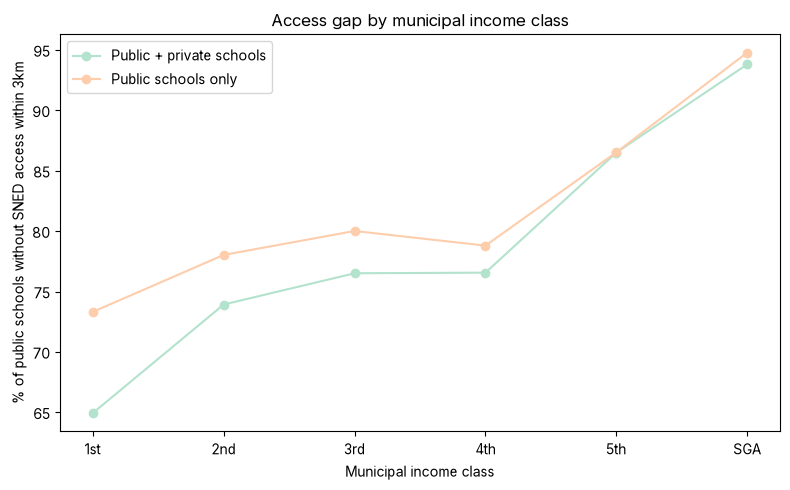

[N] Public-only: 46,258 schools across 1,634 municipalities | Public+private: 53,731 schools across 1,635 municipalities considered.


In [29]:
def summarize_access_by_income(lgu_df, label):
    g = (
        lgu_df.groupby('income_class_display', dropna=False)
        .agg(n_lgus=('psgc_municity', 'nunique'),
             n_public_schools=('n_public_schools', 'sum'),
             n_with_access=('n_with_access', 'sum'),
             n_without_access=('n_without_access', 'sum'),
             n_lgus_no_facility=('lgu_has_no_facility_at_all', 'sum'))
        .reindex(INCOME_CLASS_PLOT_ORDER)
        .reset_index()
    )
    g['pct_without_access']   = g['n_without_access'] / g['n_public_schools']
    g['pct_lgus_no_facility'] = g['n_lgus_no_facility'] / g['n_lgus']
    g['facility_definition']  = label
    return g

access_gap_public   = summarize_access_by_income(pub_lgu_enriched, 'Public schools only')
access_gap_pubpriv  = summarize_access_by_income(pubpriv_lgu_enriched, 'Public + private schools')
access_gap_by_income = pd.concat([access_gap_public, access_gap_pubpriv], ignore_index=True)
display(access_gap_by_income)

viz_data = exclude_missing_unmatched(access_gap_by_income)
fig, ax = plt.subplots(figsize=(8, 5))
for i, (label, sub) in enumerate(viz_data.groupby('facility_definition')):
    ax.plot(chart_labels(sub['income_class_display'].astype(str)), sub['pct_without_access'] * 100,
            marker='o', label=label, color=PASTEL2[i])
ax.set_ylabel('% of public schools without SNED access within 3km')
ax.set_xlabel('Municipal income class')
ax.set_title('Access gap by municipal income class')
ax.legend()
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
# plt.savefig(FIGURES / "rq5_access_gradient_by_income_class.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"[N] Public-only: {access_gap_public['n_public_schools'].sum():,.0f} schools across {access_gap_public['n_lgus'].sum():,.0f} municipalities | "
      f"Public+private: {access_gap_pubpriv['n_public_schools'].sum():,.0f} schools across {access_gap_pubpriv['n_lgus'].sum():,.0f} municipalities considered.")

,income_class_display,median,p75,p90,n,facility_definition
0,1st,1.2640,2.15100,2.6572,7629.0,Public facilities only
1,2nd,1.2770,2.24500,2.7150,1559.0,Public facilities only
2,3rd,1.4170,2.25600,2.6830,1213.0,Public facilities only
3,4th,1.3640,2.23050,2.6836,800.0,Public facilities only
4,5th,0.8920,1.91300,2.6978,85.0,Public facilities only
5,SGA (No Income Classification),2.2780,2.66300,2.7956,5.0,Public facilities only
6,Missing (blank in source),1.3495,1.93450,2.4383,114.0,Public facilities only
7,Unmatched (failed merge),NaN,NaN,NaN,NaN,Public facilities only
8,1st,1.2040,2.02500,2.5850,12140.0,Public + Private facilities
9,2nd,1.1580,2.09900,2.6700,2041.0,Public + Private facilities


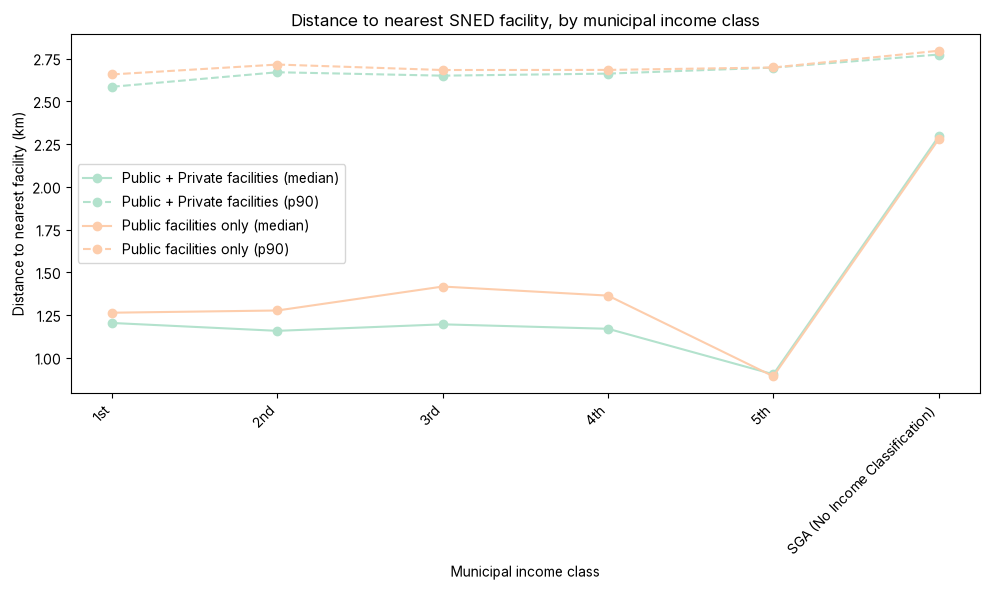

[N] Public-only: 11,405 schools-with-access | Public+private: 16,937 schools-with-access considered (distance stats are conditional on already having a facility within 3km).


In [30]:
# Distance decay, bands
def distance_by_income(summary_df, label):
    g = (
        summary_df.groupby('income_class_display', dropna=False)['nearest_facility_km']
        .agg(median='median', p75=lambda s: s.quantile(0.75), p90=lambda s: s.quantile(0.90), n='count')
        .reindex(INCOME_CLASS_PLOT_ORDER)
        .reset_index()
    )
    g['facility_definition'] = label
    return g

dist_public  = distance_by_income(pub_summary_enriched, 'Public facilities only')
dist_pubpriv = distance_by_income(pubpriv_summary_enriched, 'Public + Private facilities')
distance_by_income_class = pd.concat([dist_public, dist_pubpriv], ignore_index=True)
display(distance_by_income_class)

viz_data = exclude_missing_unmatched(distance_by_income_class)
fig, ax = plt.subplots(figsize=(10, 6))
for i, (label, sub) in enumerate(viz_data.groupby('facility_definition')):
    ax.plot(sub['income_class_display'].astype(str), sub['median'], marker='o', label=f'{label} (median)', color=PASTEL2[i])
    ax.plot(sub['income_class_display'].astype(str), sub['p90'], marker='o', linestyle='--', label=f'{label} (p90)', color=PASTEL2[i])
ax.set_ylabel('Distance to nearest facility (km)')
ax.set_xlabel('Municipal income class')
ax.set_title('Distance to nearest SNED facility, by municipal income class')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig(FIGURES / "rq5_distance_decay_by_income_class.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"[N] Public-only: {dist_public['n'].sum():,.0f} schools-with-access | Public+private: {dist_pubpriv['n'].sum():,.0f} schools-with-access considered "
      f"(distance stats are conditional on already having a facility within 3km).")

distance_band,0-1km,1-2km,2-3km,3km+ (no access)
income_class_display,,,,
1st,42.9,31.4,25.7,0.0
2nd,45.2,27.5,27.3,0.0
3rd,44.7,26.4,28.9,0.0
4th,46.0,25.4,28.5,0.0
5th,51.7,25.3,23.0,0.0
SGA (No Income Classification),0.0,33.3,66.7,0.0
Missing (blank in source),35.3,40.0,24.7,0.0
Unmatched (failed merge),NaN,NaN,NaN,NaN


distance_band,0-1km,1-2km,2-3km
income_class_display,,,
1st,42.9,31.4,25.7
2nd,45.2,27.5,27.3
3rd,44.7,26.4,28.9
4th,46.0,25.4,28.5
5th,51.7,25.3,23.0
SGA (No Income Classification),0.0,33.3,66.7
Missing (blank in source),35.3,40.0,24.7
Unmatched (failed merge),NaN,NaN,NaN


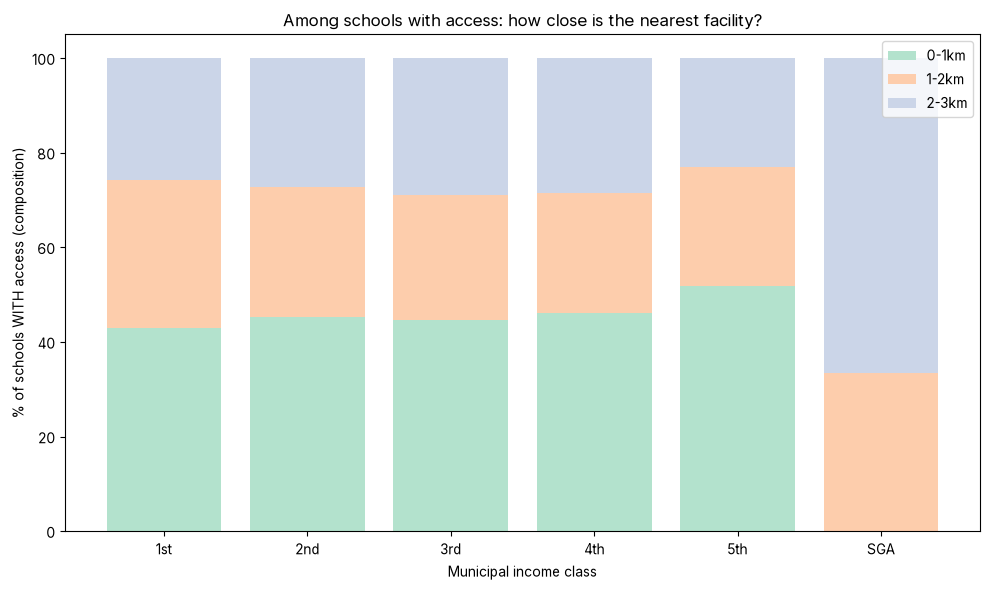

[N] 54,119 schools considered (54,117 of them have access and are shown in the conditional/composition table+chart above).


In [31]:
DISTANCE_BANDS = [0, 1, 2, 3, np.inf]
DISTANCE_BAND_LABELS = ['0-1km', '1-2km', '2-3km', '3km+ (no access)']

def add_distance_band(df, col='nearest_facility_km'):
    df = df.copy()
    df['distance_band'] = pd.cut(df[col], bins=DISTANCE_BANDS, labels=DISTANCE_BAND_LABELS, right=False, include_lowest=True)
    return df

# Uses the public+private population (see Part 4 intro) — every SNED facility is public,
# so this reflects the full universe of learners who might need one.
pubpriv_summary_bands = add_distance_band(pubpriv_summary_enriched)

distance_band_by_income = (
    pd.crosstab(pubpriv_summary_bands['income_class_display'], pubpriv_summary_bands['distance_band'], normalize='index') * 100
).reindex(index=INCOME_CLASS_PLOT_ORDER, columns=DISTANCE_BAND_LABELS)
display(distance_band_by_income.round(1))

has_access_only = pubpriv_summary_bands[pubpriv_summary_bands['distance_band'] != '3km+ (no access)']
distance_band_conditional_on_access = (
    pd.crosstab(has_access_only['income_class_display'], has_access_only['distance_band'], normalize='index') * 100
).reindex(index=INCOME_CLASS_PLOT_ORDER, columns=DISTANCE_BAND_LABELS[:-1])
display(distance_band_conditional_on_access.round(1))

viz_data = distance_band_conditional_on_access.loc[[c for c in INCOME_CLASS_VIZ_ORDER if c in distance_band_conditional_on_access.index]]
fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(len(viz_data))
for i, band in enumerate(DISTANCE_BAND_LABELS[:-1]):
    ax.bar(chart_labels(viz_data.index.astype(str)), viz_data[band], bottom=bottom, label=band, color=PASTEL2[i])
    bottom = bottom + viz_data[band].values
ax.set_ylabel('% of schools WITH access (composition)')
ax.set_xlabel('Municipal income class')
ax.set_title('Among schools with access: how close is the nearest facility?')
ax.legend()
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
# plt.savefig(FIGURES / "rq5_distance_band_composition.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"[N] {pubpriv_summary_bands['population_school_id'].nunique():,} schools considered "
      f"({len(has_access_only):,} of them have access and are shown in the conditional/composition table+chart above).")

### **F. Additionals**

In [35]:
# Which SCHOOLS carry the largest Mainstreamed LWD caseload.
TOP_N_SCHOOLS_MAINSTREAMED = 25

mainstreamed_by_school = (
    program_by_school[program_by_school['Program'] == 'Mainstreamed']
    .groupby('beis_school_id', as_index=False)['total_learners'].sum()
    .rename(columns={'beis_school_id': 'school_id', 'total_learners': 'n_mainstreamed_lwd'})
)

mainstreamed_by_school_named, unmatched_mainstreamed = merge_with_diagnostics(
    mainstreamed_by_school,
    school_income_ref[['school_id', 'school_name', 'sector', 'psgc_region_name',
                        'psgc_province_name', 'psgc_municity_name', 'income_class_display']],
    on='school_id', left_name='mainstreamed_by_school', right_name='school_income_ref')
if len(unmatched_mainstreamed):
    print(f"{len(unmatched_mainstreamed):,} schools with Mainstreamed learners could not be matched "
          f"to a name/geography record -- shown below:")
    display(unmatched_mainstreamed.head(3))

mainstreamed_by_school_named['region_short'] = (
    mainstreamed_by_school_named['psgc_region_name']
    .map(REGION_SHORT).fillna(mainstreamed_by_school_named['psgc_region_name'])
)

top_mainstreamed_schools = (
    mainstreamed_by_school_named.sort_values('n_mainstreamed_lwd', ascending=False).head(TOP_N_SCHOOLS_MAINSTREAMED)
)

# print(f"Top {TOP_N_SCHOOLS_MAINSTREAMED} schools nationally by number of Mainstreamed learners with disabilities:")
# display(top_mainstreamed_schools[['school_name', 'sector', 'region_short', 'psgc_province_name',
                                    # 'psgc_municity_name', 'income_class_display', 'n_mainstreamed_lwd']])

print(f"\n[N] {mainstreamed_by_school['school_id'].nunique():,} schools nationally report >=1 Mainstreamed "
      f"learner | {mainstreamed_by_school['n_mainstreamed_lwd'].sum():,.0f} Mainstreamed learner-records considered.")

[MERGE] mainstreamed_by_school -> school_income_ref  (on=school_id)
  37,637 / 37,822 rows matched (99.5%)
  185 rows unmatched (0.5%)
185 schools with Mainstreamed learners could not be matched to a name/geography record -- shown below:


,school_id,n_mainstreamed_lwd,school_name,sector,psgc_region_name,psgc_province_name,psgc_municity_name,income_class_display
5124,108248,59.0,NaN,NaN,NaN,NaN,NaN,NaN
20318,133221,3.0,NaN,NaN,NaN,NaN,NaN,NaN
22500,137345,2.0,NaN,NaN,NaN,NaN,NaN,NaN



[N] 37,822 schools nationally report >=1 Mainstreamed learner | 401,095 Mainstreamed learner-records considered.


In [36]:
# UPDATE to previous cell - flag whether each school is itself a SNED facility 
facility_flags = facility_roster[['school_id', 'is_ilrc', 'is_sped_center', 'is_sned']].copy()
facility_flags['is_any_facility'] = facility_flags[['is_ilrc', 'is_sped_center', 'is_sned']].any(axis=1)
facility_flags['facility_type_dedup'] = np.select(
    [facility_flags['is_ilrc'], facility_flags['is_sped_center'], facility_flags['is_sned']],
    ['ILRC', 'SPED Center', 'SNED school'],
    default='Not a facility'
)

mainstreamed_by_school_named = mainstreamed_by_school_named.merge(
    facility_flags[['school_id', 'is_any_facility', 'facility_type_dedup']], on='school_id', how='left'
)
mainstreamed_by_school_named['is_any_facility'] = mainstreamed_by_school_named['is_any_facility'].fillna(False)
mainstreamed_by_school_named['facility_type_dedup'] = mainstreamed_by_school_named['facility_type_dedup'].fillna('Not a facility')

top_mainstreamed_schools = (
    mainstreamed_by_school_named.sort_values('n_mainstreamed_lwd', ascending=False).head(TOP_N_SCHOOLS_MAINSTREAMED)
)

print(f"Top {TOP_N_SCHOOLS_MAINSTREAMED} schools nationally by number of Mainstreamed learners with disabilities "
      f"(flagged for whether the school is itself an ILRC/SPED Center/SNED-implementing facility):")
display(top_mainstreamed_schools[['school_name', 'sector', 'region_short', 'psgc_province_name',
                                    'psgc_municity_name', 'income_class_display',
                                    'n_mainstreamed_lwd', 'is_any_facility', 'facility_type_dedup']])

n_facility_in_top = int(top_mainstreamed_schools['is_any_facility'].sum())
print(f"\n{n_facility_in_top} of the top {TOP_N_SCHOOLS_MAINSTREAMED} schools by Mainstreamed caseload are "
      f"themselves a SNED facility; {TOP_N_SCHOOLS_MAINSTREAMED - n_facility_in_top} are ordinary schools "
      f"with no such designation.")

Top 25 schools nationally by number of Mainstreamed learners with disabilities (flagged for whether the school is itself an ILRC/SPED Center/SNED-implementing facility):


,school_name,sector,region_short,psgc_province_name,psgc_municity_name,income_class_display,n_mainstreamed_lwd,is_any_facility,facility_type_dedup
28769,Governor Ferrer Memorial National High School ...,Public,CALABARZON,Cavite,City of General Trias,1st,590.0,False,Not a facility
27220,E. Moralizon National Vocational High School,Public,Davao Region,Davao Oriental,Manay,1st,523.0,False,Not a facility
28080,Pinagbuhatan High School,Public,NCR,City of Pasig,City of Pasig,1st,429.0,False,Not a facility
36023,Jose Fabella Memorial School,Public,NCR,City of Mandaluyong,City of Mandaluyong,1st,415.0,False,Not a facility
16903,Manuel Lugod Central School,Public,Northern Mindanao,Misamis Oriental,City of Gingoog,1st,382.0,True,SNED school
27264,Davao City National High School,Public,Davao Region,City of Davao,City of Davao,1st,363.0,False,Not a facility
26803,Dumingag National High School,Public,Zamboanga Peninsula,Zamboanga del Sur,Dumingag,1st,352.0,False,Not a facility
27473,Lutayan National High School,Public,SOCCSKSARGEN,Sultan Kudarat,Lutayan,1st,349.0,False,Not a facility
18173,Davao City Special School,Public,Davao Region,City of Davao,City of Davao,1st,335.0,True,ILRC
36024,Ilaya Barangka Integrated School,Public,NCR,City of Mandaluyong,City of Mandaluyong,1st,331.0,False,Not a facility



8 of the top 25 schools by Mainstreamed caseload are themselves a SNED facility; 17 are ordinary schools with no such designation.


### **G. Exports**

In [38]:
# ==========================================================================
# EXPORT — LQ of diagnosed / manifestation learners, by region and by income class.
# ==========================================================================
EXPORT_DIR = DATA / "exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

def _tidy_lq(result, group_order, group_type):
    """Stacks one category_concentration() result's 3 wide (Category x group) frames
    into one tidy long table: Category, group_type, group, n_learners,
    pct_share_within_category, location_quotient."""
    long = pd.DataFrame({
        'n_learners': result['raw_counts'][group_order].stack(),
        'pct_share_within_category': result['share_of_category'][group_order].stack(),
        'location_quotient': result['location_quotient'][group_order].stack(),
    })
    long.index = long.index.set_names(['Category', 'group'])
    long = long.reset_index()
    long.insert(1, 'group_type', group_type)
    return long

def _export_category_lq(region_result, income_result, abbr_map, filename):
    tbl = pd.concat([
        _tidy_lq(region_result, REGION_ORDER, 'region'),
        _tidy_lq(income_result, INCOME_CLASS_VIZ_ORDER, 'income_class'),  # excludes Missing/Unmatched; keeps SGA
    ], ignore_index=True)
    tbl['Category_abbr'] = tbl['Category'].map(abbr_map)
    tbl[['pct_share_within_category', 'location_quotient']] = tbl[['pct_share_within_category', 'location_quotient']].round(3)
    tbl.to_csv(EXPORT_DIR / filename, index=False)
    print(f"Saved {len(tbl):,} rows -> {EXPORT_DIR / filename}")
    return tbl

diagnosed_lq_export = _export_category_lq(
    diagnosed_by_region, diagnosed_by_income, DIAGNOSED_ABBR, "rq5_lq_diagnosed_categories.csv")
manifestation_lq_export = _export_category_lq(
    manifestation_by_region, manifestation_by_income, MANIFESTATION_ABBR, "rq5_lq_manifestation_categories.csv")

Saved 264 rows -> c:\Users\Lanz Railey Fermin\Desktop\ecair_work\sned-analysis\data\exports\rq5_lq_diagnosed_categories.csv
Saved 192 rows -> c:\Users\Lanz Railey Fermin\Desktop\ecair_work\sned-analysis\data\exports\rq5_lq_manifestation_categories.csv
